In [1]:
# ======================================
# 📌 Hybrid Ant Lion + Whale Optimization (Tomato Leaf Dataset)
# ======================================

import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# ✅ Dataset
base_dir = 'augmented_split_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

IMG_SIZE = 256
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_directory(train_dir, target_size=(IMG_SIZE, IMG_SIZE),
                                        batch_size=BATCH_SIZE, class_mode='categorical',
                                        shuffle=True, seed=42)
val_gen = datagen.flow_from_directory(val_dir, target_size=(IMG_SIZE, IMG_SIZE),
                                      batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = datagen.flow_from_directory(test_dir, target_size=(IMG_SIZE, IMG_SIZE),
                                       batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

num_classes = train_gen.num_classes

# ✅ CNN Base Model
def build_base_cnn(dropout_rate=0.5, learning_rate=1e-4):
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ✅ Fitness Function
def evaluate_fitness(params):
    learning_rate, dropout_rate = params
    model = build_base_cnn(dropout_rate=dropout_rate, learning_rate=learning_rate)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        callbacks=[EarlyStopping(patience=2, monitor='val_loss')],
        verbose=0
    )
    val_acc = history.history['val_accuracy'][-1]
    return val_acc

# ✅ Bounds: [LR, Dropout]
bounds = np.array([
    [1e-5, 1e-3],
    [0.3, 0.6]
])

# ✅ Hybrid ALO + WOA
def hybrid_alo_woa(num_agents=5, max_iter=8):
    dim = bounds.shape[0]
    X = np.random.uniform(bounds[:, 0], bounds[:, 1], (num_agents, dim))
    fitness = np.array([evaluate_fitness(x) for x in X])
    elite = X[np.argmax(fitness)]
    elite_score = np.max(fitness)
    archive = X.copy()

    a_decay = 2 / max_iter

    for t in range(max_iter):
        a = 2 - t * a_decay
        for i in range(num_agents):
            if t < max_iter // 2:
                # ✅ ALO Phase
                antlion = archive[np.random.randint(num_agents)]
                rand_walk = np.random.uniform(bounds[:, 0], bounds[:, 1])
                X[i] = (antlion + rand_walk) / 2.0
            else:
                # ✅ Whale Optimization Phase
                r = np.random.rand()
                A = 2 * a * r - a
                C = 2 * np.random.rand()
                l = np.random.uniform(-1, 1)
                p = np.random.rand()

                if p < 0.5:
                    if abs(A) < 1:
                        D = abs(C * elite - X[i])
                        X[i] = elite - A * D
                    else:
                        rand_idx = np.random.randint(num_agents)
                        D = abs(C * X[rand_idx] - X[i])
                        X[i] = X[rand_idx] - A * D
                else:
                    D = abs(elite - X[i])
                    X[i] = D * np.exp(0.5 * l) * np.cos(2 * np.pi * l) + elite

            # ✅ Clip to bounds
            X[i] = np.clip(X[i], bounds[:, 0], bounds[:, 1])

        fitness = np.array([evaluate_fitness(x) for x in X])
        archive = X.copy()

        best_idx = np.argmax(fitness)
        if fitness[best_idx] > elite_score:
            elite = X[best_idx]
            elite_score = fitness[best_idx]

        print(f"Generation {t+1}/{max_iter} | Best Validation Accuracy: {elite_score:.4f}")

    return elite, elite_score

# ✅ Run Optimization
best_params, best_score = hybrid_alo_woa(num_agents=5, max_iter=8)
print("\n✅ Best Hyperparameters (ALO + WOA):")
print(f"Learning Rate: {best_params[0]:.6f}")
print(f"Dropout Rate : {best_params[1]:.2f}")
print(f"Best Validation Accuracy: {best_score:.4f}")


Found 21421 images belonging to 10 classes.
Found 4586 images belonging to 10 classes.
Found 4602 images belonging to 10 classes.


2025-06-23 19:30:43.371571: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-06-23 19:30:43.371609: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-06-23 19:30:43.371621: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-06-23 19:30:43.371648: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-23 19:30:43.371666: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/simarkalsi/Projects/leafClassification/leaf/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class shoul

Generation 1/8 | Best Validation Accuracy: 0.8855
Generation 2/8 | Best Validation Accuracy: 0.8855
Generation 3/8 | Best Validation Accuracy: 0.9180
Generation 4/8 | Best Validation Accuracy: 0.9180
Generation 5/8 | Best Validation Accuracy: 0.9180
Generation 6/8 | Best Validation Accuracy: 0.9180
Generation 7/8 | Best Validation Accuracy: 0.9180
Generation 8/8 | Best Validation Accuracy: 0.9180

✅ Best Hyperparameters (ALO + WOA):
Learning Rate: 0.000428
Dropout Rate : 0.58
Best Validation Accuracy: 0.9180


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ✅ Final CNN with ALO + WOA Optimized Parameters
def build_final_cnn():
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.58),  # ✅ from ALO + WOA
        layers.Dense(train_gen.num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.000428),  # ✅ from ALO + WOA
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ✅ Callbacks
checkpoint = ModelCheckpoint('hybrid_alo_woa_best_model.keras', monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# ✅ Train
model = build_final_cnn()
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[checkpoint, early_stop, lr_schedule],
    verbose=1
)

# ✅ Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n🧪 Final Test Accuracy (ALO + WOA): {test_acc:.4f}")


Epoch 1/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 71s 98ms/step - accuracy: 0.4465 - loss: 1.6337 - val_accuracy: 0.5456 - val_loss: 1.3005 - learning_rate: 4.2800e-04
Epoch 2/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 64s 96ms/step - accuracy: 0.7134 - loss: 0.8401 - val_accuracy: 0.5683 - val_loss: 1.5790 - learning_rate: 4.2800e-04
Epoch 3/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.7940 - loss: 0.6135 - val_accuracy: 0.8349 - val_loss: 0.4646 - learning_rate: 4.2800e-04
Epoch 4/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.8340 - loss: 0.4937 - val_accuracy: 0.8578 - val_loss: 0.4039 - learning_rate: 4.2800e-04
Epoch 5/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.8613 - loss: 0.4139 - val_accuracy: 0.8509 - val_loss: 0.4551 - learning_rate: 4.2800e-04
Epoch 6/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 65s 98ms/step - accuracy: 0.8818 - loss: 0.3554 - val_accuracy: 0.8703 - val_loss: 0.3985 - learning_rate: 4.2800e-04
Epoch 7/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/ste

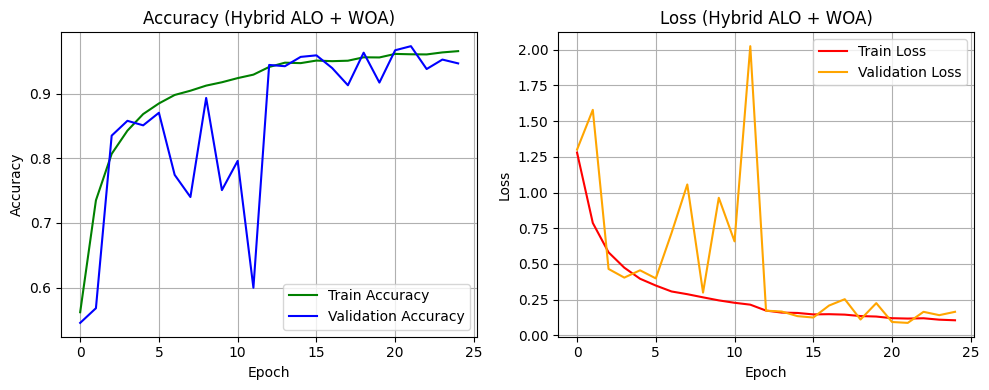

In [3]:
# ✅ Accuracy & Loss Graphs
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Accuracy (Hybrid ALO + WOA)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss (Hybrid ALO + WOA)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()